In [1]:
!pip install datasets

In [2]:
from datasets import load_dataset

In [3]:
dataset = load_dataset("dair-ai/emotion")

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [4]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [7]:
import pandas as pd
train_df =dataset["train"].to_pandas()
validation_df =dataset["validation"].to_pandas()
test_df =dataset["test"].to_pandas()


In [8]:
train_df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [13]:
train_df.duplicated().sum()

np.int64(1)

In [14]:
train_df.drop_duplicates(inplace=True)

In [16]:
train_df.dropna()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3
...,...,...
15995,i just had a very brief time in the beanbag an...,0
15996,i am now turning and i feel pathetic that i am...,0
15997,i feel strong and good overall,1
15998,i feel like this was such a rude comment and i...,3


In [17]:
train_df.isnull().sum()

,0
text,0
label,0


In [18]:
train_df['label'].value_counts()

,count
label,
1,5361
0,4666
3,2159
4,1937
2,1304
5,572


In [11]:
validation_df.head()

,text,label
0,im feeling quite sad and sorry for myself but ...,0
1,i feel like i am still looking at a blank canv...,0
2,i feel like a faithful servant,2
3,i am just feeling cranky and blue,3
4,i can have for a treat or if i am feeling festive,1


In [19]:
validation_df.duplicated().sum()


np.int64(0)

In [20]:
validation_df.drop_duplicates(inplace=True)

In [21]:
validation_df.isnull().sum()

,0
text,0
label,0


In [22]:
validation_df['label'].value_counts()

,count
label,
1,704
0,550
3,275
4,212
2,178
5,81


In [23]:
validation_df.dropna()

,text,label
0,im feeling quite sad and sorry for myself but ...,0
1,i feel like i am still looking at a blank canv...,0
2,i feel like a faithful servant,2
3,i am just feeling cranky and blue,3
4,i can have for a treat or if i am feeling festive,1
...,...,...
1995,im having ssa examination tomorrow in the morn...,0
1996,i constantly worry about their fight against n...,1
1997,i feel its important to share this info for th...,1
1998,i truly feel that if you are passionate enough...,1


In [12]:
test_df.head()

,text,label
0,im feeling rather rotten so im not very ambiti...,0
1,im updating my blog because i feel shitty,0
2,i never make her separate from me because i do...,0
3,i left with my bouquet of red and yellow tulip...,1
4,i was feeling a little vain when i did this one,0


In [24]:
test_df.duplicated().sum()

np.int64(0)

In [25]:
test_df.drop_duplicates(inplace=True)

In [26]:
test_df.isnull().sum()

,0
text,0
label,0


In [27]:
test_df['label'].value_counts()

,count
label,
1,695
0,581
3,275
4,224
2,159
5,66


In [28]:
test_df.dropna()

,text,label
0,im feeling rather rotten so im not very ambiti...,0
1,im updating my blog because i feel shitty,0
2,i never make her separate from me because i do...,0
3,i left with my bouquet of red and yellow tulip...,1
4,i was feeling a little vain when i did this one,0
...,...,...
1995,i just keep feeling like someone is being unki...,3
1996,im feeling a little cranky negative after this...,3
1997,i feel that i am useful to my people and that ...,1
1998,im feeling more comfortable with derby i feel ...,1


In [29]:
df =pd.concat([train_df,validation_df,test_df],axis=0,ignore_index=True)

In [30]:
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [34]:
df.shape

(19999, 2)

In [33]:
df.columns

Index(['text', 'label'], dtype='object')

In [35]:
df['label'].value_counts()

,count
label,
1,6760
0,5797
3,2709
4,2373
2,1641
5,719


In [36]:
x=df['text']
y=df['label']

In [37]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42 ,stratify=y)

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer
Vectorizer = TfidfVectorizer()
x_train_tfidf=Vectorizer.fit_transform(x_train)
x_test_tfidf=Vectorizer.transform(x_test)
print(x_train_tfidf.shape)
print(x_test_tfidf.shape)

(15999, 15230)
(4000, 15230)


In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
lr_model = LogisticRegression(random_state=42)
nb_model = MultinomialNB()
svm_model = SVC(random_state=42)

lr_model.fit(x_train_tfidf, y_train)
nb_model.fit(x_train_tfidf, y_train)
svm_model.fit(x_train_tfidf, y_train)

lr_pred = lr_model.predict(x_test_tfidf)
nb_pred = nb_model.predict(x_test_tfidf)
svm_pred = svm_model.predict(x_test_tfidf)




In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
lr_pred = lr_model.predict(x_test_tfidf)
nb_pred = nb_model.predict(x_test_tfidf)
svm_pred = svm_model.predict(x_test_tfidf)
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, average='weighted')
lr_recall = recall_score(y_test, lr_pred, average='weighted')
lr_f1 = f1_score(y_test, lr_pred, average='weighted')

nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred, average='weighted')
nb_recall = recall_score(y_test, nb_pred, average='weighted')
nb_f1 = f1_score(y_test, nb_pred, average='weighted')

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred, average='weighted')
svm_recall = recall_score(y_test, svm_pred, average='weighted')
svm_f1 = f1_score(y_test, svm_pred, average='weighted')

print("Logistic Regression:")
print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1 Score:", lr_f1)
print("\nNaive Bayes:")
print("Accuracy:", nb_accuracy)
print("Precision:", nb_precision)
print("Recall:", nb_recall)
print("F1 Score:", nb_f1)
print("\nSVM:")
print("Accuracy:", svm_accuracy)
print("Precision:", svm_precision)
print("Recall:", svm_recall)
print("F1 Score:", svm_f1)

Logistic Regression:
Accuracy: 0.866
Precision: 0.867782439796277
Recall: 0.866
F1 Score: 0.862035253020815

Naive Bayes:
Accuracy: 0.638
Precision: 0.7178784333175229
Recall: 0.638
F1 Score: 0.54512098644741

SVM:
Accuracy: 0.85775
Precision: 0.8617363924308384
Recall: 0.85775
F1 Score: 0.8531261740838808


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [43]:
from sklearn.metrics import classification_report
print("Logistic Regression:")
print(classification_report(y_test, lr_pred))
print("\nNaive Bayes:")
print(classification_report(y_test, nb_pred))
print("\nSVM:")
print(classification_report(y_test, svm_pred))


Logistic Regression:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      1159
           1       0.84      0.95      0.89      1352
           2       0.85      0.65      0.73       328
           3       0.90      0.80      0.85       542
           4       0.87      0.79      0.83       475
           5       0.89      0.53      0.66       144

    accuracy                           0.87      4000
   macro avg       0.87      0.77      0.81      4000
weighted avg       0.87      0.87      0.86      4000


Naive Bayes:
              precision    recall  f1-score   support

           0       0.68      0.91      0.78      1159
           1       0.58      0.99      0.73      1352
           2       1.00      0.02      0.03       328
           3       0.95      0.18      0.30       542
           4       0.94      0.13      0.24       475
           5       0.00      0.00      0.00       144

    accuracy                           0.6

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


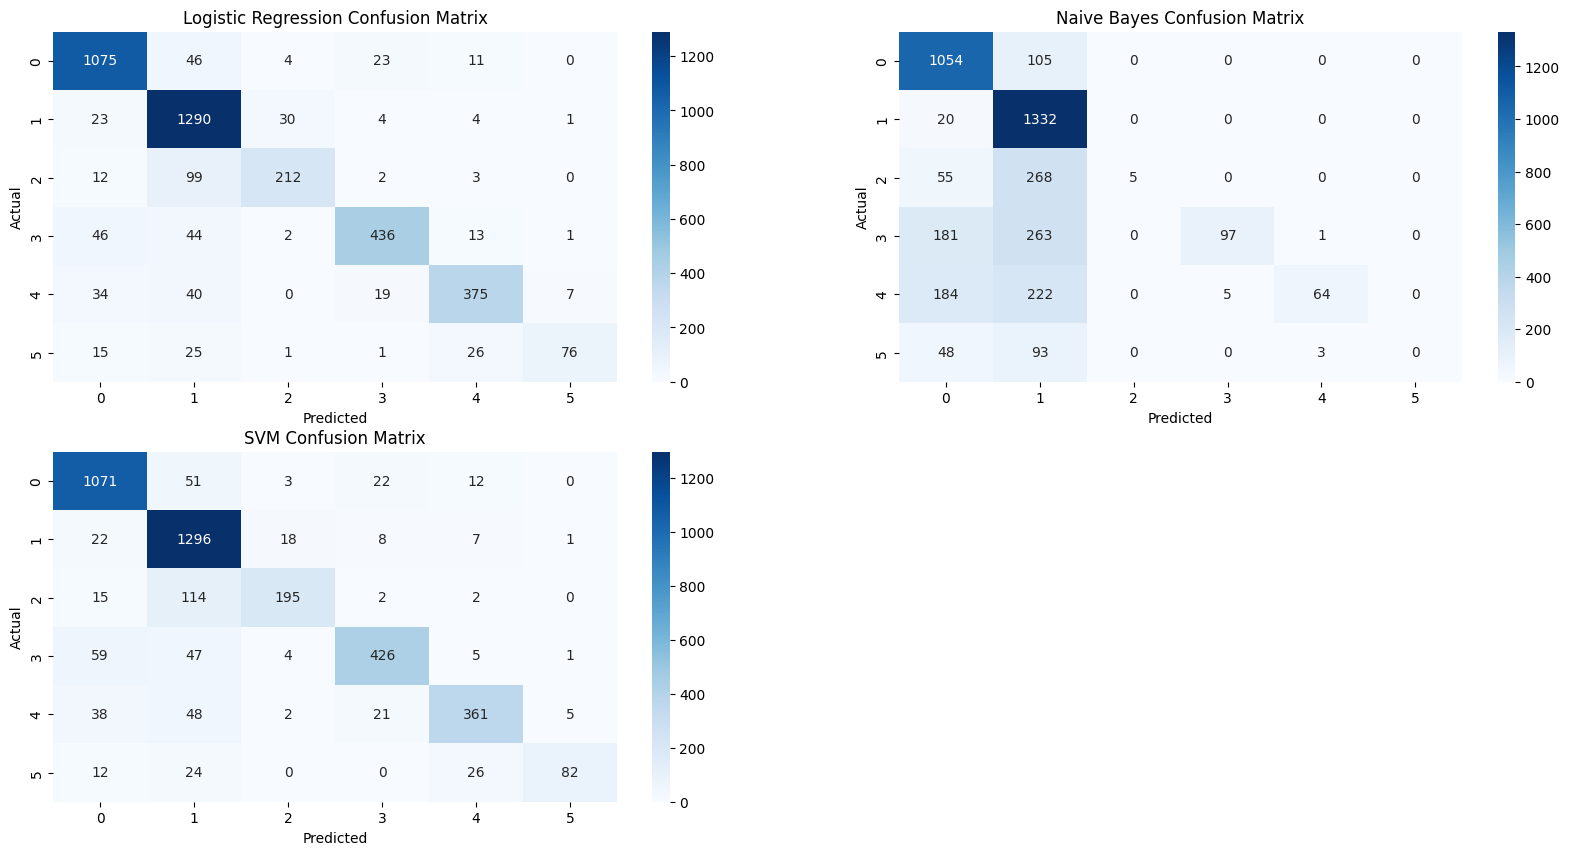

In [51]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
lr_cm = confusion_matrix(y_test, lr_pred)
nb_cm = confusion_matrix(y_test, nb_pred)
svm_cm = confusion_matrix(y_test, svm_pred)
plt.figure(figsize=(20, 10))
plt.subplot(2, 2, 1)
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.subplot(2, 2, 2)
sns.heatmap(nb_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.subplot(2, 2, 3)
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [52]:
result = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'SVM'],
    'Accuracy': [lr_accuracy, nb_accuracy, svm_accuracy],
    'Precision': [lr_precision, nb_precision, svm_precision],
    'Recall': [lr_recall, nb_recall, svm_recall],
    'F1 Score': [lr_f1, nb_f1, svm_f1]
})
print(result)

                 Model  Accuracy  Precision   Recall  F1 Score
0  Logistic Regression   0.86600   0.867782  0.86600  0.862035
1          Naive Bayes   0.63800   0.717878  0.63800  0.545121
2                  SVM   0.85775   0.861736  0.85775  0.853126


In [59]:
import joblib
joblib.dump(lr_model, 'lr_model.pkl')




['lr_model.pkl']

In [60]:
joblib.dump(Vectorizer, 'vectorizer.pkl')

['vectorizer.pkl']

In [62]:
text="I am so Happy"
text_tfidf=Vectorizer.transform([text])
prediction=lr_model.predict(text_tfidf)
print(prediction)

[1]


In [70]:
import os
os.listdir()
from google.colab import files
files.download("lr_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>